# Higgs Boson Machine Learning Challenge: End-to-End Classification Pipeline

This notebook builds, tunes, and evaluates a supervised binary classification pipeline for the Kaggle Higgs Boson Machine Learning Challenge.

The task is to classify simulated particle collision events as either signal (`s`, Higgs boson event) or background (`b`, noise/background event).


## Assignment Coverage

- Data preprocessing and exploratory analysis
- Missing-value handling for the Higgs `-999` sentinel values
- Imbalance check and sampling strategy
- Logistic regression, random forest, and XGBoost models
- Hold-out precision, recall, F1-score, and ROC-AUC
- Stratified k-fold cross-validation
- Grid search tuning for the strongest model
- Top feature analysis by permutation importance


In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
DATA_PATH = ROOT / "data" / "training.csv"
OUTPUT_DIR = ROOT / "outputs" / "real"
SCRIPT_PATH = ROOT / "src" / "higgs_pipeline.py"

print(f"Data exists: {DATA_PATH.exists()} -> {DATA_PATH}")
print(f"Pipeline script exists: {SCRIPT_PATH.exists()} -> {SCRIPT_PATH}")


Data exists: True -> /Users/poweruser/Documents/Higgs_Boson_Assignment_Submission/data/training.csv
Pipeline script exists: True -> /Users/poweruser/Documents/Higgs_Boson_Assignment_Submission/src/higgs_pipeline.py


## 1. Data Loading and EDA

The Kaggle training file contains 250,000 rows. The target column is `Label`, with `s` mapped to 1 for signal and `b` mapped to 0 for background. `EventId` and `Weight` are excluded from the predictor matrix for the supervised classification models.


In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
display(df.head())
display(df["Label"].value_counts().rename_axis("label").reset_index(name="count"))


(250000, 33)


,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584,b
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389,b
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,5.446378,b
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333,b


,label,count
0,b,164333
1,s,85667


## 2. Preprocessing Rationale

The Higgs dataset has no categorical predictors, so feature encoding is not needed. The dataset does contain `-999` sentinel values for undefined kinematic quantities. These are converted to missing values inside the pipeline and imputed with each feature's median. Median imputation is used because the physics-derived continuous variables can be skewed and can contain long tails.

All numeric features are standardized after imputation. This is especially important for logistic regression because its optimization is sensitive to feature scale. The class distribution is imbalanced, with more background than signal events, so random oversampling is applied inside the training folds only.


In [3]:
feature_columns = [c for c in df.columns if c not in ["EventId", "Weight", "Label"]]
missing_sentinel_counts = (df[feature_columns] == -999).sum().sort_values(ascending=False)
display(
    missing_sentinel_counts.head(10)
    .rename_axis("feature")
    .reset_index(name="sentinel_-999_count")
)

class_counts = df["Label"].value_counts()
minority_to_majority = class_counts.min() / class_counts.max()
print(f"Minority-to-majority ratio: {minority_to_majority:.3f}")


,feature,sentinel_-999_count
0,PRI_jet_subleading_phi,177457
1,PRI_jet_subleading_eta,177457
2,DER_deltaeta_jet_jet,177457
3,DER_mass_jet_jet,177457
4,DER_prodeta_jet_jet,177457
5,PRI_jet_subleading_pt,177457
6,DER_lep_eta_centrality,177457
7,PRI_jet_leading_phi,99913
8,PRI_jet_leading_pt,99913
9,PRI_jet_leading_eta,99913


Minority-to-majority ratio: 0.521


## 3. Run the Reproducible Pipeline

This cell runs the same Python pipeline used for the submitted results. It is skipped when the expected real-output files already exist.


In [4]:
expected_outputs = [
    OUTPUT_DIR / "metrics_baseline.csv",
    OUTPUT_DIR / "cross_validation.csv",
    OUTPUT_DIR / "metrics_tuned.csv",
    OUTPUT_DIR / "top_features.csv",
    OUTPUT_DIR / "summary.md",
]

if not all(path.exists() for path in expected_outputs):
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    command = [
        sys.executable,
        str(SCRIPT_PATH),
        "--data",
        str(DATA_PATH),
        "--output-dir",
        str(OUTPUT_DIR),
        "--cv-folds",
        "3",
        "--n-jobs",
        "1",
    ]
    subprocess.run(command, check=True)
else:
    print("Existing real-output files found. Skipping retraining.")


Existing real-output files found. Skipping retraining.


## 4. Baseline Hold-Out Evaluation

Each model is evaluated on a stratified 20% hold-out test set. The comparison uses precision, recall, F1-score, and ROC-AUC rather than accuracy alone.


,model,precision,recall,f1_score,roc_auc
0,XGBoost,0.707831,0.825658,0.762218,0.906346
1,Random Forest,0.765413,0.757952,0.761665,0.904884
2,Logistic Regression,0.588440,0.759995,0.663305,0.813296


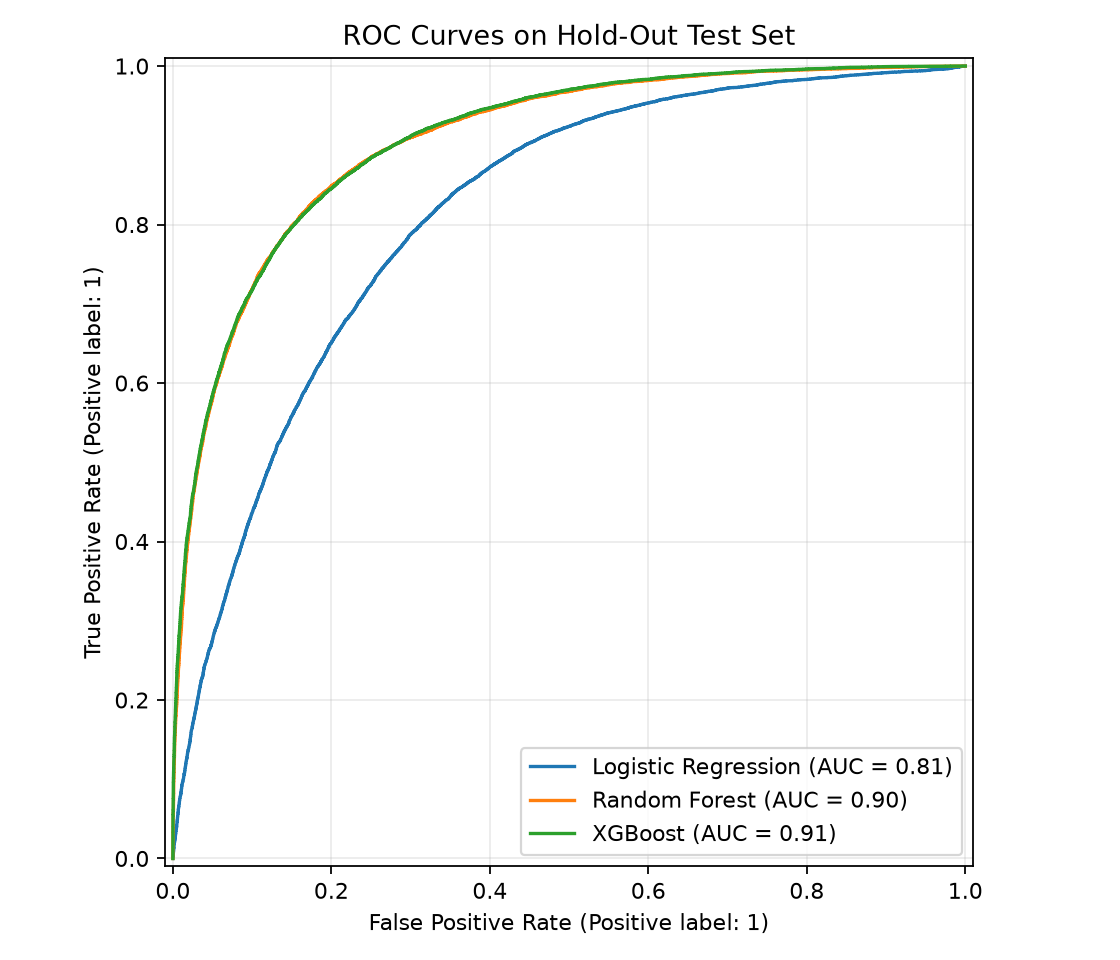

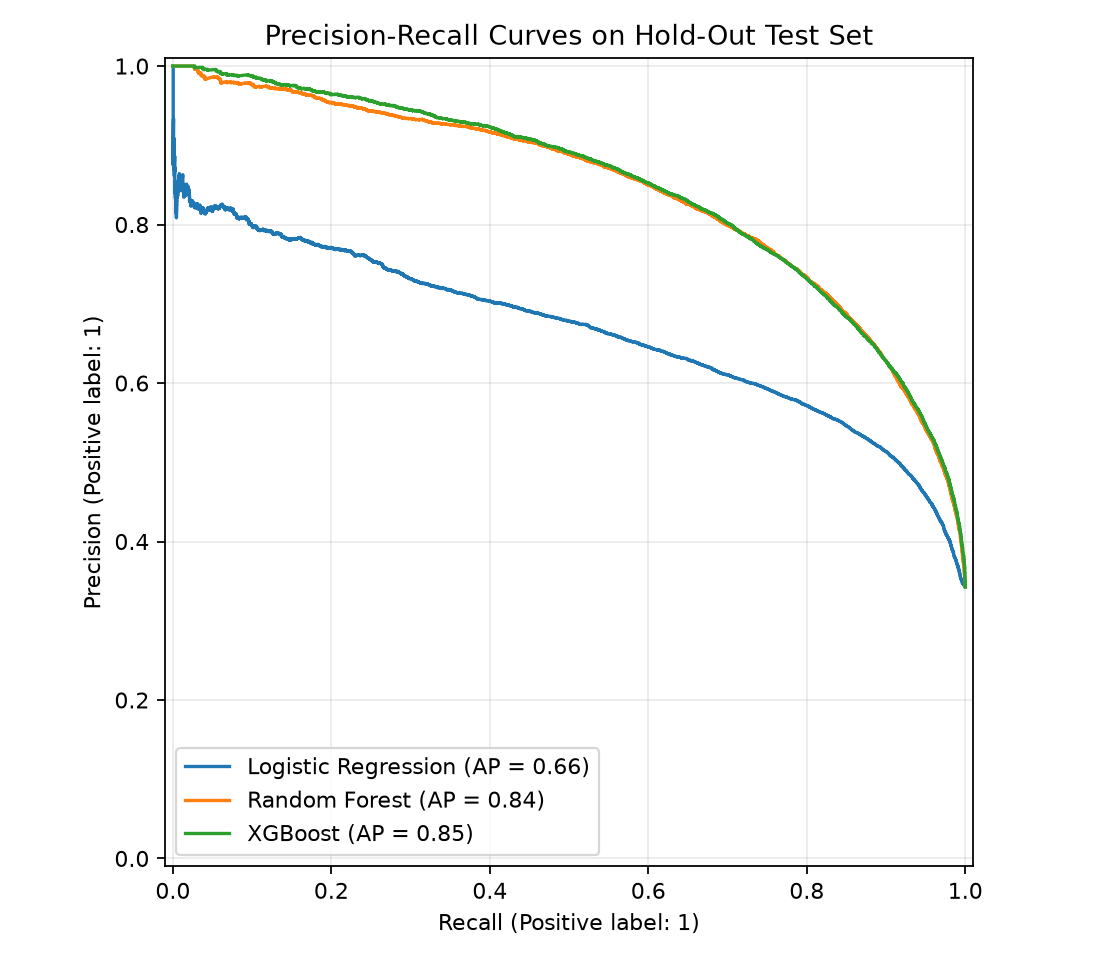

In [5]:
baseline_metrics = pd.read_csv(OUTPUT_DIR / "metrics_baseline.csv")
display(baseline_metrics)
display(Image(filename=str(OUTPUT_DIR / "roc_curves.png")))
display(Image(filename=str(OUTPUT_DIR / "precision_recall_curves.png")))


## 5. Cross-Validation

Stratified k-fold cross-validation checks whether the model ranking is stable across folds.


In [6]:
cv_results = pd.read_csv(OUTPUT_DIR / "cross_validation.csv")
display(cv_results)


,model,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,XGBoost,0.710999,0.001086,0.823911,0.001070,0.763301,0.000393,0.907278,0.000386
1,Random Forest,0.765481,0.001439,0.757293,0.000837,0.761364,0.000629,0.905983,0.000563
2,Logistic Regression,0.589286,0.001319,0.767355,0.003077,0.666628,0.000670,0.816032,0.000388


## 6. Hyperparameter Tuning

The highest-performing baseline model by ROC-AUC is selected for grid search. For this run, XGBoost was selected and tuned with ROC-AUC as the scoring metric.


In [7]:
tuned_metrics = pd.read_csv(OUTPUT_DIR / "metrics_tuned.csv")
display(tuned_metrics)

with open(OUTPUT_DIR / "best_model_grid_search.json", "r", encoding="utf-8") as f:
    best_params = json.load(f)
display(best_params)


,model,precision,recall,f1_score,roc_auc
0,Tuned XGBoost,0.716013,0.826008,0.767088,0.90931


{'selected_model': 'XGBoost',
 'scoring': 'roc_auc',
 'best_score_cv_roc_auc': 0.9099667472452827,
 'best_params': {'model__learning_rate': 0.08,
  'model__max_depth': 5,
  'model__n_estimators': 350,
  'model__subsample': 0.85}}

## 7. Feature Importance

Permutation importance is computed on the hold-out set. A larger value means shuffling that feature caused a larger ROC-AUC decrease.


,feature,importance_mean,importance_std
0,DER_mass_MMC,0.096607,0.003344
1,DER_mass_transverse_met_lep,0.035720,0.002901
2,DER_mass_vis,0.032968,0.001749
3,PRI_tau_pt,0.023984,0.001497
4,DER_deltar_tau_lep,0.010553,0.000885
5,DER_met_phi_centrality,0.010293,0.000854
6,PRI_jet_leading_eta,0.006142,0.000809
7,DER_lep_eta_centrality,0.005528,0.000793
8,PRI_lep_eta,0.004362,0.000807
9,PRI_tau_eta,0.003286,0.001046


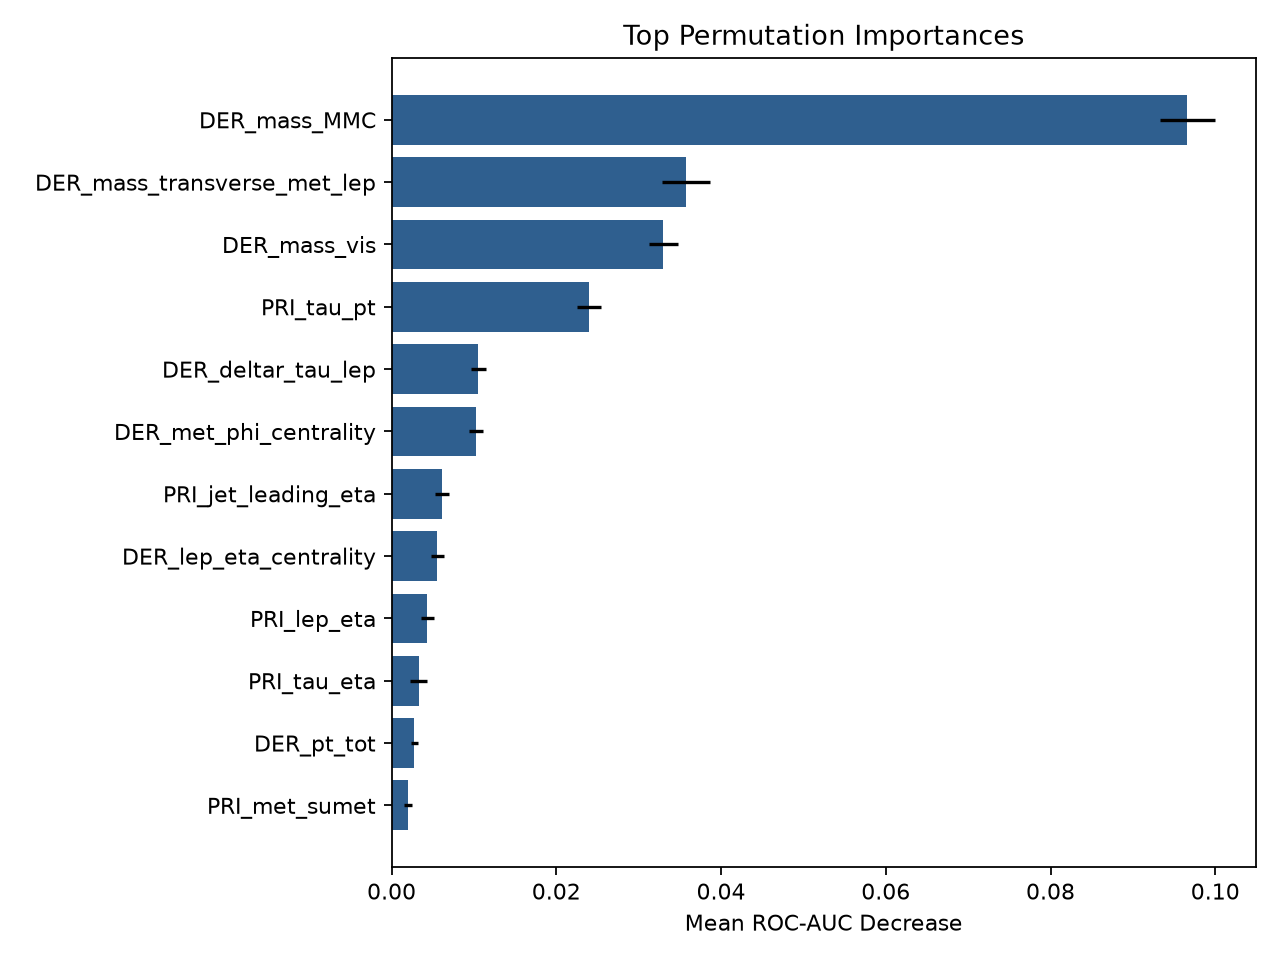

In [8]:
top_features = pd.read_csv(OUTPUT_DIR / "top_features.csv")
display(top_features.head(10))
display(Image(filename=str(OUTPUT_DIR / "top_features.png")))


## 8. Written Summary

The generated written summary below contains the final model selection rationale, tuning impact, and top feature analysis.


In [9]:
display(Markdown((OUTPUT_DIR / "summary.md").read_text(encoding="utf-8")))


# Higgs Boson Classification Summary

## Dataset and preprocessing

The dataset contains 250,000 rows and 30 model features.
The target is binary: background is encoded as 0 and Higgs signal is encoded as 1.
Class counts were 164,333 background events and 85,667 signal events.
The minority-to-majority ratio was 0.521. Random oversampling was applied only inside the training folds.

The Kaggle Higgs data uses -999 as a sentinel for undefined kinematic quantities. Those values were converted to missing values and imputed with the median within each training split. Median imputation was selected because these variables are continuous and can contain skewed tails. Standard scaling was applied after imputation for every model so logistic regression received well-conditioned inputs.

There were no categorical predictors, so no feature encoding was required.

## Model comparison

Three supervised models were trained: logistic regression, random forest, and XGBoost gradient boosting.

| model               |   precision |   recall |     f1 |   roc_auc |
|:--------------------|------------:|---------:|-------:|----------:|
| XGBoost             |      0.7078 |   0.8257 | 0.7622 |    0.9063 |
| Random Forest       |      0.7654 |   0.758  | 0.7617 |    0.9049 |
| Logistic Regression |      0.5884 |   0.76   | 0.6633 |    0.8133 |

The strongest baseline model by ROC-AUC was XGBoost with ROC-AUC 0.9063.

Cross-validation was used to check model stability:

| model               |   precision_mean |   precision_std |   recall_mean |   recall_std |   f1_mean |   f1_std |   roc_auc_mean |   roc_auc_std |
|:--------------------|-----------------:|----------------:|--------------:|-------------:|----------:|---------:|---------------:|--------------:|
| XGBoost             |           0.711  |          0.0011 |        0.8239 |       0.0011 |    0.7633 |   0.0004 |         0.9073 |        0.0004 |
| Random Forest       |           0.7655 |          0.0014 |        0.7573 |       0.0008 |    0.7614 |   0.0006 |         0.906  |        0.0006 |
| Logistic Regression |           0.5893 |          0.0013 |        0.7674 |       0.0031 |    0.6666 |   0.0007 |         0.816  |        0.0004 |

## Hyperparameter tuning

The selected model for tuning was XGBClassifier.
Best cross-validated ROC-AUC during grid search: 0.9100.
Hold-out ROC-AUC after tuning: 0.9093.
Best parameters: `{"model__learning_rate": 0.08, "model__max_depth": 5, "model__n_estimators": 350, "model__subsample": 0.85}`.

Tuning was assessed with ROC-AUC because the task is a signal-vs-background ranking problem and accuracy alone can hide poor signal recall.

## Top features

Permutation importance on the hold-out set identified the three strongest drivers:

| feature                     |   importance_mean |   importance_std |
|:----------------------------|------------------:|-----------------:|
| DER_mass_MMC                |           0.09661 |          0.00334 |
| DER_mass_transverse_met_lep |           0.03572 |          0.0029  |
| DER_mass_vis                |           0.03297 |          0.00175 |

Higher permutation importance means shuffling that feature caused a larger drop in ROC-AUC, so the model depended on that variable more heavily for separating signal from background.

## Generated files

- `metrics_baseline.csv`
- `cross_validation.csv`
- `best_model_grid_search.json`
- `top_features.csv`
- `target_distribution.png`
- `roc_curves.png`
- `precision_recall_curves.png`
- `top_features.png`
